# Phase diagram calculations for nitrogen

In this example, we will construct a PT phase diagram for nitrogen using empirical relations like the Antoine equation and approximations such as the Clausius-Clapeyron equation.

## Antoine equation

The Antoine equation is an emprical equation of the form

$$ \log P^\mathrm{sub}(T) = A - \frac{B}{T + C} $$

In [2]:
# Antoine equation given parameters A, B, and C
# Pressure is returned in Pa
def P_antoine(A, B, C, T):
    return 10**(A - B/(T + C))*100000

## Clausius-Clapeyron equation

Given $\Delta^\mathrm{sat}\underline{H}$, $T_1$, $P_1$, and $T_2$, return $P_2$ by the equation

$$ \ln \frac{P^\mathrm{sat}(T_2)}{P^\mathrm{sat}(T_1)} = \frac{-\Delta^\mathrm{sat}\underline{H}}{R} \left ( \frac{1}{T_2} - \frac{1}{T_1} \right ) $$

In [3]:
# Clausius-Clapeyron equation
# Pressures in Pa, Temperatues in K
# Enthalpy in J / mol

import numpy as np
from scipy import constants
R = constants.R

def P_CC(delta_sat_H, T1, P1, T2):
    return P1*np.exp(-delta_sat_H/R*(1/T2-1/T1))

## $P-T$ plot for nitrogen

### Data for nitrogen -- sublimation, VLE, critical point, and triple point

NIST Webbook data is included below:

https://webbook.nist.gov/cgi/cbook.cgi?ID=C7727379&Units=SI&Mask=4#Thermo-Phase

We can find other thermodynamic data in:

The solid phase of nitrogen, including estimates of the melting (fusion) line are available on wikipedia with references:

https://en.wikipedia.org/wiki/Solid_nitrogen

Streng (Miscibility and Compatibility of Some Liquid and Solidified Gases at Low Temperature, J. Chem. Eng. Data, 1971, 16, 357) gives the melting temperature at 1 atm as $ T^\text{fus} = 63.3 $ K.

The enthalpy of sublimation is measured by NIST and reported in:

H. Shakeel, H. Wei, and J. Pomeroy, Measurements of enthalpy of sublimation of Ne, N2, O2, Ar, CO2, Kr, Xe, and H2O using a double paddle oscillator, The Journal of Chemical Thermodynamics 118, 127 (2018).



In [4]:
# Data for nitrogen
# Molecular weight
MW = 28.0134 # g/mol

# Critical parameters and acentricity
Pc = 33.978*100000 # Critical pressure in Pa
Tc = 126.19 # Critical temp in K
Vc = 1/(11.18*1000) # Critical volume in m^3/mol (original is 11.18 mol/l)
omega = 0.040 # acentric factor

# Triple point
T_triple = 63.14 # temp in K
P_triple = 0.1252*100000 # pressure in Pa

# Normal melting point
T_melt = 63.3 # in K
P_melt = 101325 # in Pa

# Antoine equation parameters
# Valid temperature range in K
T_Antoine_min = 63.14
T_Antoine_max = 126

A = 3.7362
B = 264.651
C = -6.788

# Enthalpy of sublimation is given by 
H_sub_1 = 7.34*1000 # J / mol, 23 to 27.5 K

# Enthalpy of vaporization
H_vap_1 = 6.1*1000 # J / mol, data from 63. to 126. K. (NIST)
H_vap_2 = 5.57*1000 # J / mol (data wikipedia)


### Solid-liquid equilibrium

Data for N2 lists the heat of fusion as

$$\Delta^\mathrm{fus}\underline{H} = 720 \text{ J/mol}$$

By the Clapeyron equation, we can then find

$$ \left ( \frac{\partial P^\mathrm{sat}}{\partial T} \right )_{\underline{G}^I = \underline{G}^{II}} = \frac{\Delta \underline{H}}{T \Delta \underline{V} }$$

As expected, this line should be quite steep. We can integrate the function to give

$$ P^\mathrm{sat}(T_2) = P^\mathrm{sat}(T_1) + \frac{\Delta \underline{H}}{\Delta \underline{V} } \ln \left ( \frac{T_2}{T_1} \right )$$

In the case for nitrogen, we have data for the triple point and normal melting point. Therefore, we can estimate the entire melting (fusion) line.

Rearranging,

$$ \Delta \underline{V} = \frac{\Delta \underline{H} \ln (T_2/T_1)}{P^\mathrm{sat}(T_2) - P^\mathrm{sat}(T_1)}$$

Using the triple and normal meltint point temperature and pressures, we can find the change in molar volume and use the Clapeyron equation to plot the melting line.

In [5]:
# Integrated Clapeyron equation
def P_clapeyron(T1, P1, T2, delta_H, delta_V):
    return P1 + delta_H/delta_V*np.log(T2/T1)

In [6]:
# Data for nitrogen

# Other data
delta_fus_H = 0.72*1000 # Heat of fusion, J/mol (Wikipedia, 0.72 kJ/mol)

# Calculate Delta V
delta_fus_V = delta_fus_H*np.log(T_melt/T_triple)/(P_melt-P_triple)

print(f"Calculated molar volume: {delta_fus_V:.2e} m^3/mol")
#print(delta_fus_H/delta_fus_V)

Calculated molar volume: 2.05e-05 m^3/mol


### Building the PT diagram plot

Text(0.5, 1.0, 'P-T diagram for nitrogen')

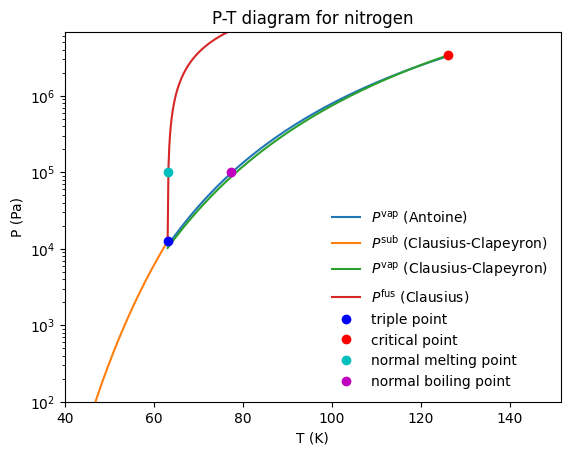

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Make a blank plot
fig, ax = plt.subplots()

# Plot the Antoine equation
T = np.arange(T_Antoine_min, T_Antoine_max+1, 1)
ax.plot(T, P_antoine(A, B, C, T), label=r"$P^\mathrm{vap}$ (Antoine)")

# Use Clausius-Clapeyron to plot the sublimation curve
T = np.linspace(24, T_triple, 300)
P = P_CC(H_sub_1,T_triple, P_triple, T)
ax.plot(T, P, label=r"$P^\mathrm{sub}$ (Clausius-Clapeyron)")

# Use Clausius-Clapeyron to plot the vaporization curve 
# starting from the critical point down
T = np.linspace(Tc, T_Antoine_min, 300)
P = P_CC(H_vap_1,Tc, Pc, T)
ax.plot(T, P, label=r"$P^\mathrm{vap}$ (Clausius-Clapeyron)")

# Use the integrated Clapeyron equation to plot the melting line
T = np.linspace(T_triple, T_triple+18, 100)
P = P_clapeyron(T_triple, P_triple, T, delta_fus_H, delta_fus_V)
ax.plot(T, P, label=r"$P^\mathrm{fus}$ (Clausius)")

# Plot the triple point
plt.plot(T_triple, P_triple, "bo", label="triple point")

# Plot the critical point
plt.plot(Tc, Pc, "ro", label="critical point")

# Plot the normal melting point (from Streng)
plt.plot(T_melt, P_melt, "co", label="normal melting point")

# Plot the normal boiling point (from Streng)
plt.plot(77.4, 101325, "mo", label="normal boiling point")

# Label and axes
plt.ylim([100,Pc*2])
plt.xlim([40,Tc*1.2])
ax.set_yscale("log")
ax.legend(frameon=True, fancybox=True, edgecolor='none')
plt.xlabel('T (K)')
plt.ylabel('P (Pa)')
plt.title('P-T diagram for nitrogen')